# SoAP — рабочая среда для анализа SOLPS-ITER

Пакет **SoAP** (`solps_analysis`) — Python-аналог MATLAB-цепочки
`read_data_3x.m` + `calc_additional.m` + plot-функций.

Два уровня работы:

1. **Workspace** — 178 переменных как в MATLAB workspace (`te`, `po`, `fna_mdf_r`, ...)
2. **Quantity** — 229 производных величин (`te_sep`, `E_r`, `Fhi_tot`, `Qrad`, ...)

Всё доступно через `watch.construct("имя")` → объект `SolpsVariable`
(данные + метаданные: unit, description, location, source, matlab_lines).


In [1]:
# 1. Загрузка watch (структурированная сетка)
from solps_analysis.core.dataset import SolpsWatch

WATCH_PATH = "/run/media/kirill/Fusion/Science/SOLPS_ITER/Watches/Globus_44644_ng_new_equ/watch_15.05.2026_11_31"  # ← укажи свой watch
watch = SolpsWatch.from_directory(WATCH_PATH)
print(watch)
print("переменных в watch:", len(watch.list_variables()))


SolpsWatch(watch_15.05.2026_11_31, nCv=3392, vars=1139, EIRENE=True)
переменных в watch: 1139


/home/kirill/projects/solps_analysis/src/solps_analysis/io/data_readers.py:98: ConversionWarning: Some errors were detected !
    Line #38 (got 8 columns instead of 17)
    Line #39 (got 8 columns instead of 17)
    Line #40 (got 8 columns instead of 17)
    Line #41 (got 8 columns instead of 17)
    Line #43 (got 8 columns instead of 17)
    Line #44 (got 8 columns instead of 17)
    Line #45 (got 8 columns instead of 17)
    Line #46 (got 8 columns instead of 17)
    Line #48 (got 9 columns instead of 17)
    Line #49 (got 9 columns instead of 17)
    Line #50 (got 9 columns instead of 17)
    Line #51 (got 9 columns instead of 17)
  data = np.genfromtxt(filepath, skip_header=1, invalid_raise=False)


In [2]:
# 2. Геометрия: регионы (таргеты, midplane, сепаратриса) — один раз
watch.compute_regions()
print("OMP ячеек:", len(watch.grid.outer_midplane_cells))
print("сепаратрисных граней:", len(watch.grid.core_sep_fcs))


OMP ячеек: 34
сепаратрисных граней: 48


In [3]:
# 3. Производные величины: полный реестр
from solps_analysis.construct import builtin  # noqa: F401 — регистрирует все @quantity
from solps_analysis.construct.registry import list_quantities_info, list_quantities
info = list_quantities_info()
print(f"всего величин: {len(info)}")
# посмотреть метаданные одной
v = watch.construct("te_sep")
print(v)
print("метаданные:", v.meta)


всего величин: 229
SolpsVariable('te_sep', shape=(1,), unit='eV', loc=cell)
метаданные: VariableMeta(name='te_sep', unit='eV', description='separatrix electron temperature (surface averaged)', location='cell', source_file='', is_constructed=True, extra={'matlab_lines': 'calc_additional.m:1117-1341'})


In [4]:
# 4. Ключевые интегральные параметры
for name in ["te_sep", "ti_sep", "n_sep", "n_e_sep", "n_D_sep",
             "n_ped", "Compr_div_sep", "Enrich_div_sep", "Qrad_tot_sum"]:
    v = watch.construct(name)
    if v is not None:
        print(f"{name:16s} = {v.data}")


te_sep           = [44.39165911]
ti_sep           = [82.94083888]
n_sep            = [1.88872108e+19 5.42899614e+17]
n_e_sep          = [0.89757557 0.02580018]
n_D_sep          = [1.        0.0287443]
n_ped            = [4.68917025e+19 1.45714939e+17]
Compr_div_sep    = [ 1.99305893 13.52777883]
Enrich_div_sep   = [1.         6.78744547]
Qrad_tot_sum     = [158229.92725102]


PlotResult(config=PlotConfig(type='1d', variable=['te', 'ti'], along='omp', log=False, include_guards=False, xlim=None, ylim=None, title=None, style='screen', style_overrides={}), fig=<Figure size 1000x600 with 1 Axes>, ax=<Axes: xlabel='R [m]'>)

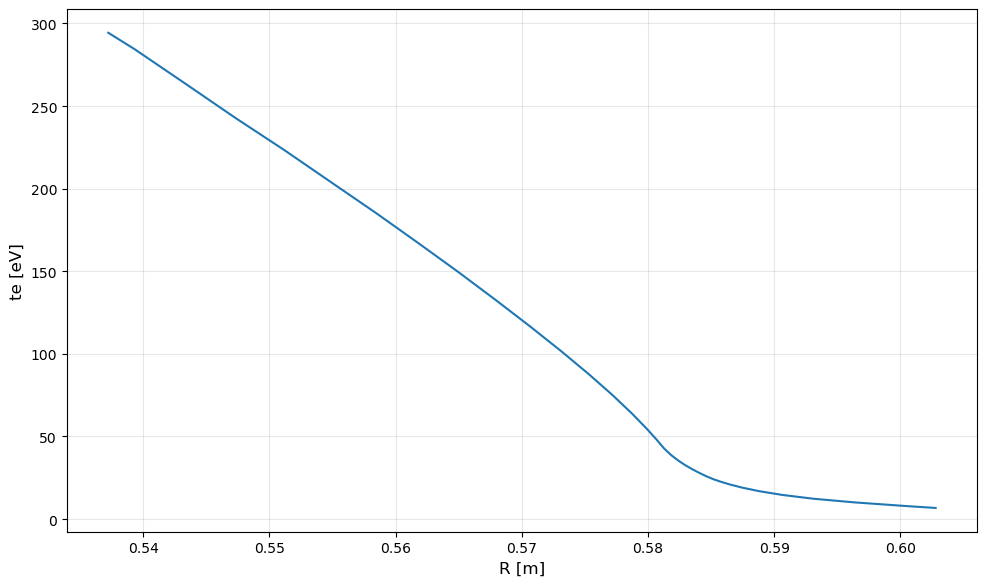

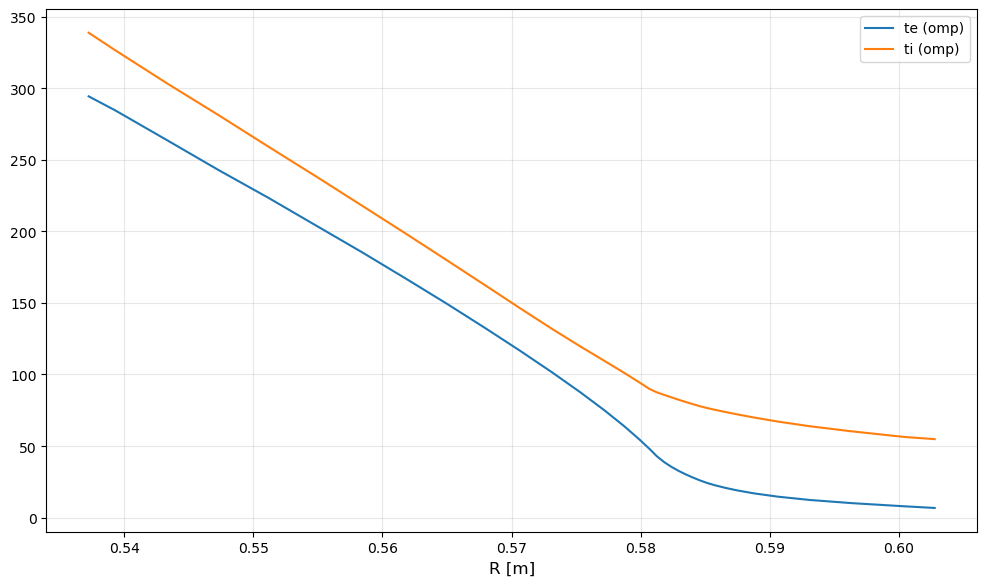

In [5]:
# 5. Графики 1D вдоль OMP (внешний мидплейн)
watch.plot("te", type="1d", along="omp")
watch.plot(["te", "ti"], type="1d", along="omp")


PlotResult(config=PlotConfig(type='2d', variable='te', along=None, log=False, include_guards=False, xlim=None, ylim=None, title=None, style='screen', style_overrides={}), fig=<Figure size 1000x600 with 1 Axes>, ax=<Axes: xlabel='R [m]', ylabel='te [eV]'>)

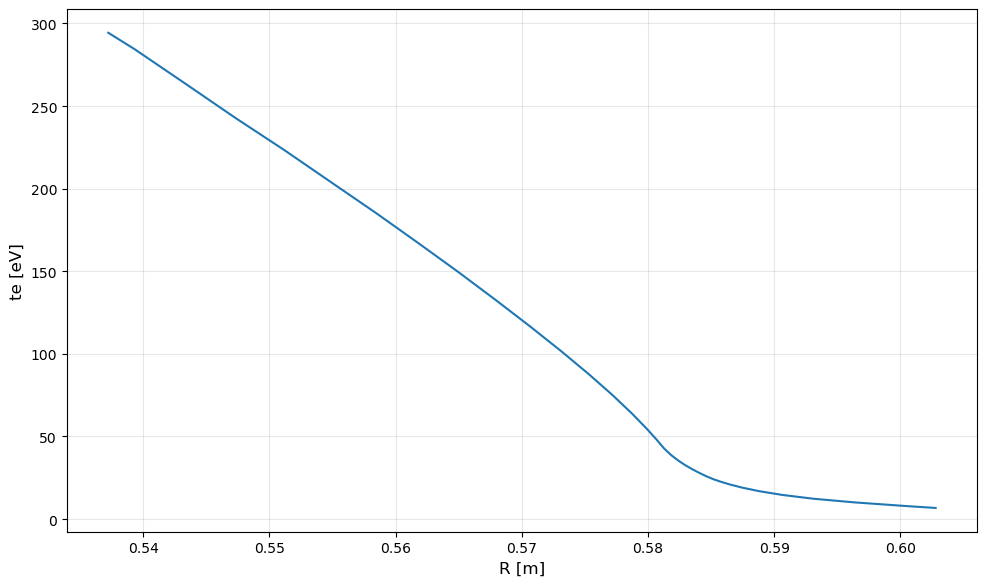

In [6]:
# 6. 2D-карта (ячейки, вершины реконструируются автоматически)
watch.plot("te", type="2d")


In [7]:
# 7. Низкоуровневый экстрактор: (x, y, xlabel, ylabel)
from solps_analysis.extract import extract_profile
x, y, xl, yl = extract_profile(watch, "te", along="omp")
print(f"профиль te вдоль {xl}: {len(x)} точек, {yl}")


профиль te вдоль R [m]: 34 точек, te [eV]


In [8]:
# 8. Workspace: MATLAB-стиль переменные напрямую
from solps_analysis.io.matlab_vars import build_workspace
ws = build_workspace(watch)
print("переменных в workspace:", len(ws))
print("te:", ws["te"].shape, "eV | fna_mdf_r:", ws["fna_mdf_r"].shape)


переменных в workspace: 178
te: (3392,) eV | fna_mdf_r: (6304, 9)


In [9]:
# 9. Как добавить СВОЮ величину (пример: тепловая энергия на объём)
from solps_analysis.construct.registry import quantity
import numpy as np

@quantity(
    name="E_thermal_per_vol",
    description="Тепловая энергия плазмы на объём (3/2 n_e T_e + 3/2 n_i T_i)",
    unit="J/m³",
    matlab_lines="energy_balance_Extended.m:en_e+en_i_int",
)
def calc_e_thermal_per_vol(watch=None, grid=None, comp=None, **kw):
    from solps_analysis.io.matlab_vars import build_workspace
    ws = build_workspace(watch)
    return 1.5 * 1.602176634e-19 * (ws["ne"] * ws["te"] + ws["na"][:, 1] * ws["ti"])

v = watch.construct("E_thermal_per_vol")
print(v, "| max =", v.data.max())


SolpsVariable('E_thermal_per_vol', shape=(3392,), unit='J/m³', loc=cell) | max = 7367.87770476765


In [10]:
# 10. Справка по именам
# Список сырых переменных:      watch.list_variables()
# Список quantity:              list_quantities()
# Метаданные любой величины:    watch.construct("E_r").meta
#   (unit, description, location, source, matlab_lines)


In [11]:
list_quantities()

['Compr_div_ped',
 'Compr_div_sep',
 'E_NEO_r',
 'E_r',
 'E_th',
 'E_thermal_per_vol',
 'E_up_r',
 'Enrich_div_sep',
 'Fch',
 'Fee',
 'Fei',
 'Fet',
 'Fh_boundary_seg',
 'Fhe_tot',
 'Fhi_tot',
 'Fna_mdf_r',
 'Fna_pump',
 'Fueling',
 'Gas_puff',
 'Hx1',
 'N_tot_B25',
 'Na_reg',
 'P_pfr',
 'Qrad',
 'Qrad_tot',
 'Qrad_tot_sum',
 'Qrads',
 'Seeding',
 'She',
 'She_entr_tar_ft',
 'She_top_tar_ft',
 'Shi',
 'Shi_dd1',
 'Shi_entr_tar_ft',
 'Shi_top_tar_ft',
 'Sna',
 'Snas',
 'Zavg',
 'Zeff',
 'c071',
 'cs',
 'cs_th',
 'csi',
 'div_fch',
 'div_fch_r',
 'div_fch_th',
 'div_fhe',
 'div_fhe_mdf',
 'div_fhe_mdf_r',
 'div_fhe_mdf_th',
 'div_fhe_qeprll',
 'div_fhi',
 'div_fhi_mdf',
 'div_fhi_mdf_r',
 'div_fhi_mdf_th',
 'div_fmo',
 'div_fmo_flo',
 'div_fmo_r',
 'div_fmo_th',
 'div_fmo_vis',
 'div_fmo_vis_BgradB',
 'div_fmo_vis_r',
 'div_fmo_vis_th',
 'div_fmo_viscurv',
 'div_fna',
 'div_fna_Dgradn_r',
 'div_fna_Dgradn_th',
 'div_fna_RhieChow',
 'div_fna_curr',
 'div_fna_dia_mdf',
 'div_fna_fha',
 'di